1. 빅테크 데이터 수집 중 (기준: ~2024년)...
2. 기업 프로필 및 1년 전 실적/주가 기반 P/E 역산 중...


$JNPR: possibly delisted; no timezone found


3. SEC EDGAR 10-K 기반 실전 관계 추출 시작 (대상: 48개 기업)...
추출된 실전 10-K 관계 수: 100


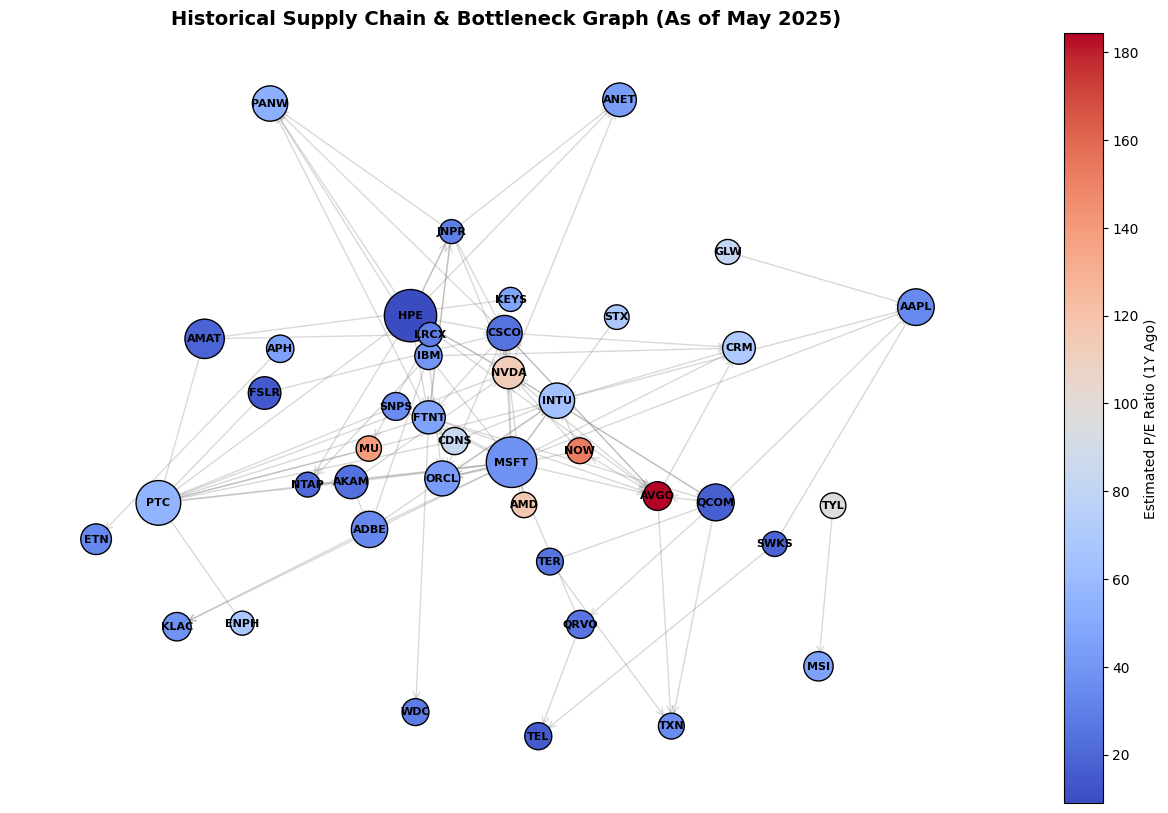

        In_Degree  Correlation      PE  Bottleneck_Score
Ticker                                                  
HPE             2        0.879    8.97            0.5585
MSFT           11        0.927   38.28            0.5118
PTC            12        0.846   55.42            0.3664
AMAT            2        0.795   19.06            0.2511
QCOM            3       -0.045   16.61            0.2012
AAPL            5        0.322   34.61            0.1973
ADBE            3        0.837   33.75            0.1905
PANW            5        0.777   53.02            0.1732
INTU            6        0.838   63.75            0.1730
CSCO            5       -0.197   24.48            0.1694
ORCL            4        0.649   42.83            0.1668
ANET            3        0.768   43.24            0.1431
AKAM            1        0.798   23.86            0.1381
FTNT            3        0.758   46.28            0.1330
CRM             4        1.000   68.81            0.1260
FSLR            0        0.851 

In [ ]:
import yfinance as yf
import requests
import json
import time
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import re
from bs4 import BeautifulSoup

# 1. 분석 대상 리스트 및 SEC 방화벽 통과용 헤더 설정
it_50_tickers = [
    'MSFT', 'AAPL', 'NVDA', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'CSCO', 'AMD', 'QCOM',
    'TXN', 'INTU', 'IBM', 'AMAT', 'MU', 'NOW', 'LRCX', 'ADI', 'PANW', 'KLAC',
    'SNPS', 'CDNS', 'MSI', 'APH', 'CDW', 'TEL', 'FTNT', 'ANET', 'KEYS', 'GLW', 
    'TER', 'STX', 'NTAP', 'FSLR', 'TYL', 'AKAM', 'GEN', 'JNPR', 'QRVO', 'SWKS', 
    'WDC', 'ENPH', 'TRMB', 'ZBRA', 'PTC', 'VRT', 'ETN', 'HPE'
]
big_tech = ['MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA']

HEADERS = {
    'User-Agent': 'Academic ResearchProject YourEmail@domain.com',  # ⚠️ SEC EDGAR 규정상 본인의 실제 이메일로 변경해야 작동합니다.
    'Accept-Encoding': 'gzip, deflate'
}

def get_ticker_to_cik():
    """IT 48개 기업 전체의 CIK 및 공식 사명 매핑 딕셔너리 (누락 무력화)"""
    local_ticker_to_cik = {
        'MSFT': '0000789019', 'AAPL': '0000320193', 'NVDA': '0001045810', 'AVGO': '0001730168', 
        'ORCL': '0001341439', 'CRM': '0001108524', 'ADBE': '0000796343', 'CSCO': '0000858877', 
        'AMD': '0000002488', 'QCOM': '0000804328', 'TXN': '0000097476', 'INTU': '0000896878', 
        'IBM': '0000051143', 'AMAT': '0000006951', 'MU': '0000723125', 'NOW': '0001373715', 
        'LRCX': '0000707549', 'ADI': '0000006281', 'PANW': '0001327568', 'KLAC': '0000319201', 
        'SNPS': '0000883241', 'CDNS': '0000813672', 'MSI': '0000068505', 'APH': '0000820313', 
        'CDW': '0001402064', 'TEL': '0001385157', 'FTNT': '0001262039', 'ANET': '0001591862', 
        'KEYS': '0001601046', 'GLW': '0000024741', 'TER': '0000097210', 'STX': '0001137789', 
        'NTAP': '0001002047', 'FSLR': '0001274494', 'TYL': '0000860731', 'AKAM': '0001086222', 
        'GEN': '0000849318', 'JNPR': '0001043604', 'QRVO': '0001602658', 'SWKS': '0000004127', 
        'WDC': '0001060394', 'ENPH': '0001463101', 'TRMB': '0000864749', 'ZBRA': '0000877212', 
        'PTC': '0000857002', 'VRT': '0001774759', 'ETN': '0001551182', 'HPE': '0001645590'
    }
    local_cik_to_name = {
        'MSFT': 'Microsoft', 'AAPL': 'Apple', 'NVDA': 'NVIDIA', 'AVGO': 'Broadcom', 
        'ORCL': 'Oracle', 'CRM': 'Salesforce', 'ADBE': 'Adobe', 'CSCO': 'Cisco Systems', 
        'AMD': 'Advanced Micro Devices', 'QCOM': 'QUALCOMM', 'TXN': 'Texas Instruments', 'INTU': 'Intuit', 
        'IBM': 'International Business Machines', 'AMAT': 'Applied Materials', 'MU': 'Micron Technology', 'NOW': 'ServiceNow', 
        'LRCX': 'Lam Research', 'ADI': 'Analog Devices', 'PANW': 'Palo Alto Networks', 'KLAC': 'KLA', 
        'SNPS': 'Synopsys', 'CDNS': 'Cadence Design Systems', 'MSI': 'Motorola Solutions', 'APH': 'Amphenol', 
        'CDW': 'CDW', 'TEL': 'TE Connectivity', 'FTNT': 'Fortinet', 'ANET': 'Arista Networks', 
        'KEYS': 'Keysight Technologies', 'GLW': 'Corning', 'TER': 'Teradyne', 'STX': 'Seagate Technology', 
        'NTAP': 'NetApp', 'FSLR': 'First Solar', 'TYL': 'Tyler Technologies', 'AKAM': 'Akamai Technologies', 
        'GEN': 'Gen Digital', 'JNPR': 'Juniper Networks', 'QRVO': 'Qorvo', 'SWKS': 'Skyworks Solutions', 
        'WDC': 'Western Digital', 'ENPH': 'Enphase Energy', 'TRMB': 'Trimble', 'ZBRA': 'Zebra Technologies', 
        'PTC': 'PTC', 'VRT': 'Vertiv Holdings', 'ETN': 'Eaton', 'HPE': 'Hewlett Packard Enterprise'
    }
    return local_ticker_to_cik, local_cik_to_name

def get_10k_url_before_may2025(ticker, cik):
    """2025년 5월 이전에 공시된 가장 최근 10-K(2024년도 결산) 보고서의 주소를 찾습니다."""
    url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    try:
        res = requests.get(url, headers=HEADERS)
        if res.status_code != 200: return None
        submissions = res.json()['filings']['recent']
        for i in range(len(submissions['form'])):
            form_type = submissions['form'][i]
            filing_date = submissions['filingDate'][i]
            if form_type == '10-K' and "2024-01-01" <= filing_date <= "2025-05-15":
                acc_num = submissions['accessionNumber'][i].replace('-', '')
                doc_name = submissions['primaryDocument'][i]
                return f"https://www.sec.gov/Archives/edgar/data/{cik}/{acc_num}/{doc_name}"
    except: pass
    return None

def final_evolution_analysis_fixed_1y_ago(tickers, customers):
    profiles = {}
    edges = []
    ticker_to_cik, ticker_to_name = get_ticker_to_cik()
    
    # 로컬 딕셔너리에 존재하는 유효 티커 필터링 (48개 완전체 반영)
    valid_tickers = [t for t in tickers if t in ticker_to_cik]
    
    # 1. 빅테크 데이터 수집 (1년 전 시점: 2024년 데이터까지만 반영)
    print("1. 빅테크 데이터 수집 중 (기준: ~2024년)...")
    cust_capex_list = []
    for t in customers:
        try:
            c = yf.Ticker(t)
            cf = c.cashflow.T
            if 'Capital Expenditure' in cf.columns:
                capex = cf['Capital Expenditure'].abs()
                capex.index = pd.to_datetime(capex.index).year
                capex = capex[capex.index <= 2024] # 1년 전 타임프레임 제한
                cust_capex_list.append(capex.groupby(capex.index).last())
        except: continue
    
    if not cust_capex_list:
        print("고객사 CAPEX 데이터를 가져올 수 없습니다.")
        return pd.DataFrame()
        
    total_capex = pd.concat(cust_capex_list, axis=1).sum(axis=1)

    # 2. 기업 프로필 및 1년 전(2025년 5월) P/E 비율 구축
    print("2. 기업 프로필 및 1년 전 실적/주가 기반 P/E 역산 중...")
    for t in valid_tickers:
        try:
            stock = yf.Ticker(t)
            info = stock.info
            
            # 1년 전(2025년 5월 중순 청문회 시점) 종가 가져오기
            hist_1y = stock.history(start="2025-05-12", end="2025-05-17")
            price_1y_ago = hist_1y['Close'].iloc[-1] if not hist_1y.empty else None
            
            # 2024년 실적 기준 EPS 추출 후 P/E 역산
            pe_1y_ago = 30  # 기본값
            try:
                fin = stock.financials.T
                fin.index = pd.to_datetime(fin.index).year
                if 2024 in fin.index and price_1y_ago is not None:
                    row_2024 = fin.loc[2024]
                    if isinstance(row_2024, pd.DataFrame): row_2024 = row_2024.iloc[0]
                    
                    eps = None
                    for col in fin.columns:
                        if 'EPS' in col or 'Earnings Per Share' in col:
                            eps = row_2024[col]
                            break
                    if (eps is None or pd.isna(eps) or eps <= 0) and 'Net Income' in row_2024:
                        net_inc = row_2024['Net Income']
                        shares = row_2024.get('Diluted Average Shares', row_2024.get('Basic Average Shares', 1))
                        eps = net_inc / shares if shares > 0 else None
                        
                    if eps and eps > 0:
                        pe_1y_ago = price_1y_ago / eps
                    else:
                        pe_1y_ago = info.get('trailingPE', 30)
                else:
                    pe_1y_ago = info.get('trailingPE', 30)
            except:
                pe_1y_ago = info.get('trailingPE', 30)
            
            profiles[t] = {
                'name': ticker_to_name[t],
                'pe': pe_1y_ago,
                'stock_obj': stock
            }
        except: continue

    # 3. SEC 10-K 원문 기반 진짜 과거 관계 추출 (Proximity Search)
    print(f"3. SEC EDGAR 10-K 기반 실전 관계 추출 시작 (대상: {len(profiles)}개 기업)...")
    rel_keywords = ['partner', 'supply', 'provide', 'infrastructure', 'platform', 'customer', 'use', 'build', 'work']

    for t in profiles.keys():
        cik = ticker_to_cik[t]
        url = get_10k_url_before_may2025(t, cik)
        if not url: continue
        
        try:
            time.sleep(0.2) # SEC DDoS 방어 오버플로우 방지 리밋
            res = requests.get(url, headers=HEADERS)
            if res.status_code != 200: continue
            
            soup = BeautifulSoup(res.text, 'html.parser')
            text = soup.get_text(separator=' ').lower()
            text = re.sub(r'\s+', ' ', text)
            
            for target_t in profiles.keys():
                if t == target_t: continue
                target_name = profiles[target_t]['name'].lower()
                
                if target_name in text or target_t.lower() in text:
                    for kw in rel_keywords:
                        pattern = rf"{kw}.{{0,150}}{target_name}"
                        if re.search(pattern, text):
                            edges.append((t, target_t))
                            break
        except: continue

    print(f"추출된 실전 10-K 관계 수: {len(edges)}")

    if not edges:
        print("추출된 과거 관계가 없습니다. 데이터 환경을 점검하세요.")
        return pd.DataFrame()

    # 4. 그래프 및 수치 분석 (1년 전 시점 수치 산출)
    G = nx.DiGraph()
    G.add_edges_from(edges)
    
    in_degrees = dict(G.in_degree())
    max_in = max(in_degrees.values()) if in_degrees else 1
    
    analysis_results = []
    for t in G.nodes():
        if t in profiles:
            try:
                rev_df = profiles[t]['stock_obj'].financials.T
                if 'Total Revenue' in rev_df.columns:
                    rev = rev_df['Total Revenue']
                    rev.index = pd.to_datetime(rev.index).year
                    rev = rev[rev.index <= 2024] # 1년 전 시점 데이터 제한
                    rev = rev.groupby(rev.index).last()
                    
                    combined = pd.DataFrame({'Capex': total_capex, 'Rev': rev}).dropna()
                    corr = combined.corr().iloc[0, 1] if len(combined) >= 2 else 0
                    
                    norm_in = in_degrees.get(t, 0) / max_in
                    # 1년 전 역산된 고유 P/E 비율 기반 GARP 스코어 계산
                    score = ((norm_in + 0.1) * (corr + 1)) / (max(profiles[t]['pe'], 5) / 10)
                    
                    analysis_results.append({
                        'Ticker': t,
                        'In_Degree': in_degrees.get(t, 0),
                        'Correlation': round(corr, 3),
                        'PE': round(profiles[t]['pe'], 2),
                        'Bottleneck_Score': round(score, 4)
                    })
            except: continue

    # 5. 데이터프레임 생성 및 인덱스 설정
    if not analysis_results:
        print("분석 결과 데이터가 생성되지 않았습니다.")
        return pd.DataFrame()

    res_df = pd.DataFrame(analysis_results)
    if 'Ticker' in res_df.columns:
        res_df = res_df.set_index('Ticker')
    
    # 6. 시각화 (노드 사이즈: Bottleneck_Score 비례, 색상: 당대 P/E 비례)
    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    node_sizes = [res_df.loc[n, 'Bottleneck_Score'] * 2000 + 300 if n in res_df.index else 300 for n in G.nodes()]
    node_colors = [profiles[n]['pe'] if n in profiles else 30 for n in G.nodes()]

    nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.coolwarm, edgecolors='black')
    nx.draw_networkx_edges(G, pos, alpha=0.3, arrowstyle='->', arrowsize=12, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    
    plt.title("Historical Supply Chain & Bottleneck Graph (As of May 2025)", fontsize=14, fontweight='bold')
    plt.colorbar(nodes, label="Estimated P/E Ratio (1Y Ago)")
    plt.axis('off')
    plt.show()

    return res_df.sort_values(by='Bottleneck_Score', ascending=False)

# 실행 및 상위 20개 기업 출력
final_report = final_evolution_analysis_fixed_1y_ago(it_50_tickers, big_tech)
if not final_report.empty:
    print(final_report.head(20))

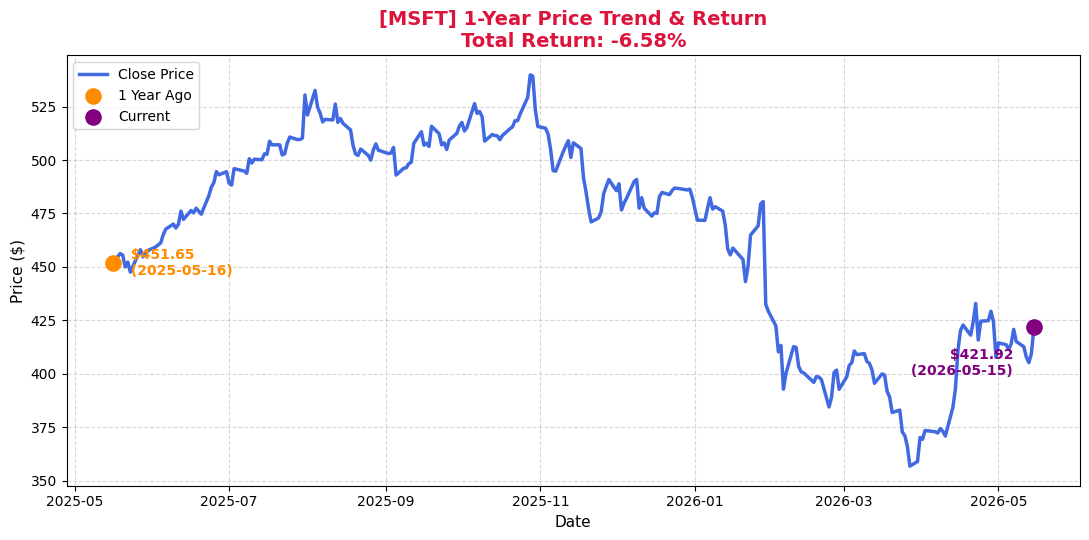

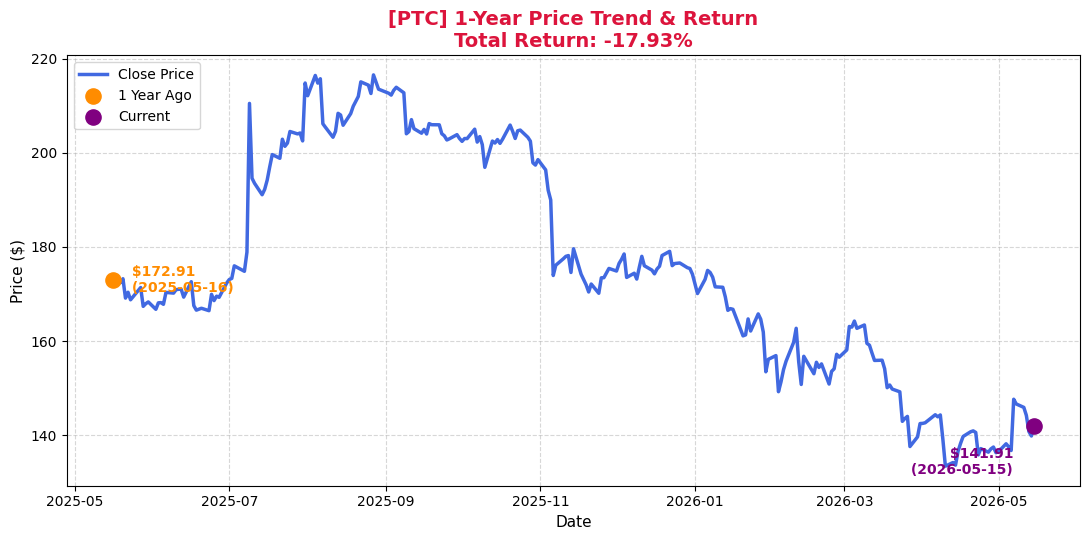

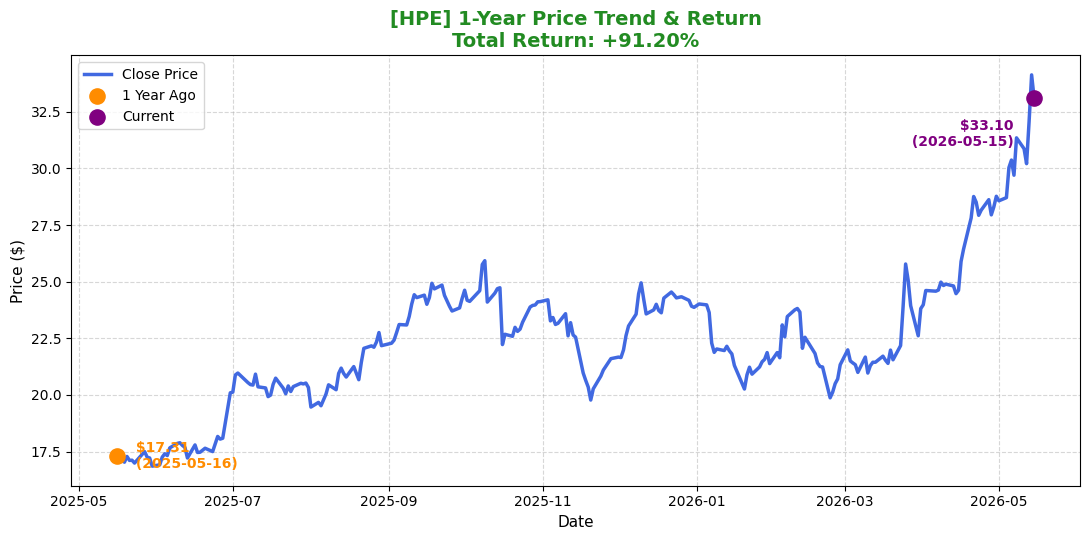

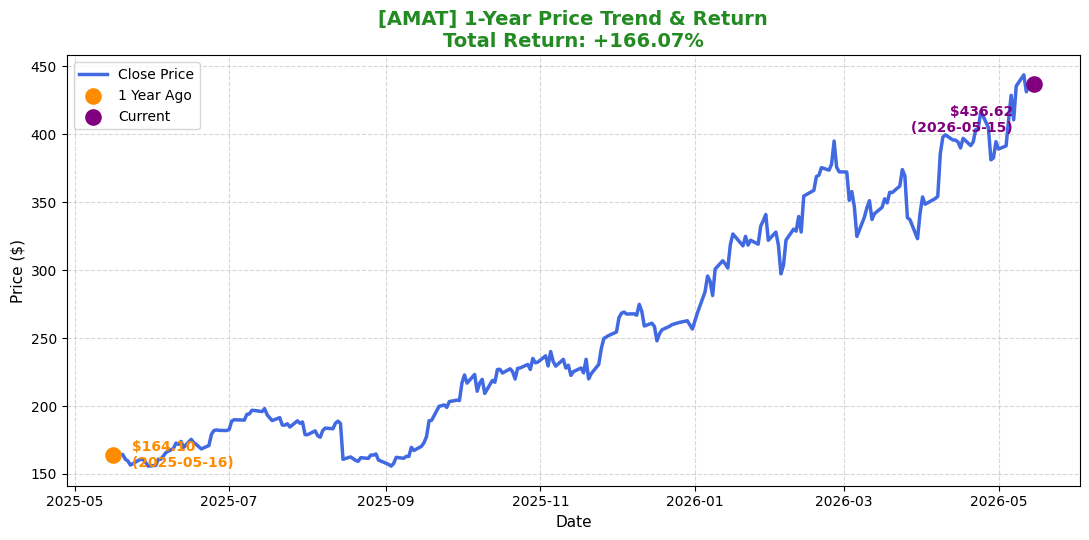

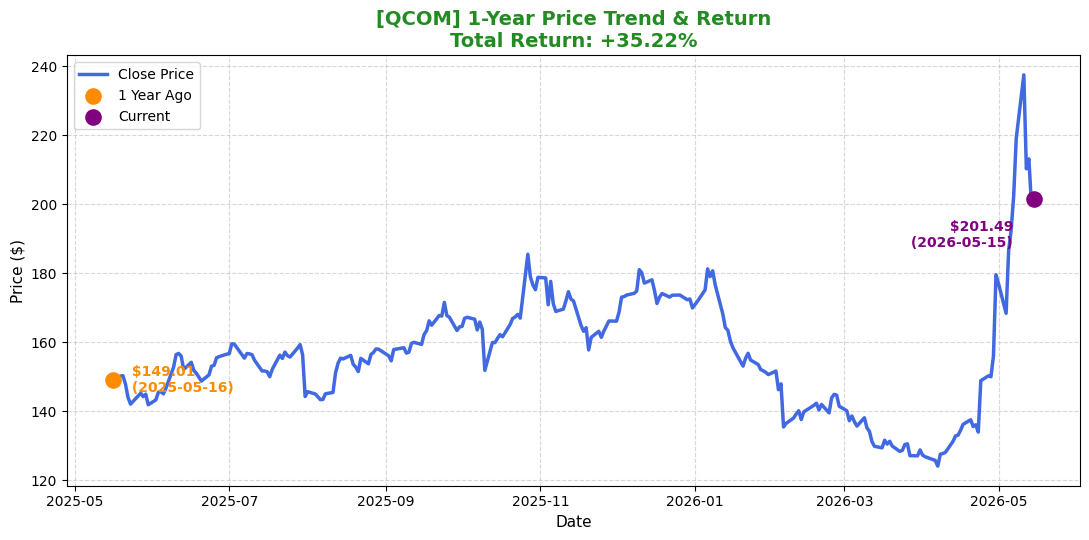

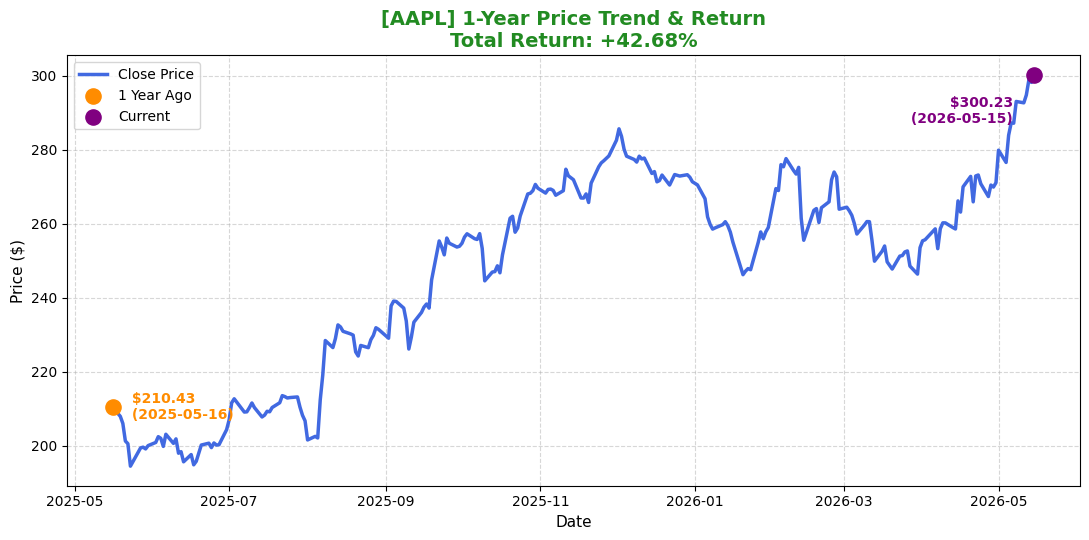

In [14]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# 분석 대상 종목 리스트
target_tickers = ['MSFT', 'PTC', 'HPE', 'AMAT', 'QCOM', 'AAPL']

for ticker in target_tickers:
    stock = yf.Ticker(ticker)
    
    # 실행 시점 기준 최근 1년(1y) 데이터 다운로드
    df = stock.history(period='1y')
    
    if df.empty:
        print(f"[{ticker}] 데이터를 가져오는 데 실패했습니다.")
        continue
        
    # ⚠️ 핵심 수정: Close 가격이 NaN인 행을 완전히 제거하여 에러 방지
    df = df.dropna(subset=['Close'])
    
    if len(df) < 2:
        print(f"[{ticker}] 유효한 데이터가 부족합니다.")
        continue
        
    # 날짜 및 주가 정보 추출
    start_date = df.index[0].strftime('%Y-%m-%d')
    end_date = df.index[-1].strftime('%Y-%m-%d')
    
    start_price = df['Close'].iloc[0]
    end_price = df['Close'].iloc[-1]
    
    # 지난 1년간의 수익률(상승률) 계산 (이제 NaN이 나오지 않습니다)
    growth_rate = ((end_price - start_price) / start_price) * 100
    
    # 그래프 그리기 시작
    plt.figure(figsize=(11, 5.5))
    plt.plot(df.index, df['Close'], label='Close Price', color='royalblue', linewidth=2.5)
    
    # 1) 1년 전 주가 고정 표시 (시작점)
    plt.scatter(df.index[0], start_price, color='darkorange', s=120, zorder=5, label='1 Year Ago')
    plt.annotate(f" ${start_price:.2f}\n ({start_date})", 
                 (df.index[0], start_price),
                 textcoords="offset points", 
                 xytext=(10, 0), 
                 ha='left', 
                 va='center',
                 fontsize=10, 
                 fontweight='bold', 
                 color='darkorange')
                 
    # 2) 현재 주가 고정 표시 (끝점)
    plt.scatter(df.index[-1], end_price, color='purple', s=120, zorder=5, label='Current')
    plt.annotate(f" ${end_price:.2f}\n ({end_date})", 
                 (df.index[-1], end_price),
                 textcoords="offset points", 
                 xytext=(-15, -15), 
                 ha='right', 
                 va='top',
                 fontsize=10, 
                 fontweight='bold', 
                 color='purple')
                 
    # 상승/하락 여부에 따른 타이틀 색상 셋팅
    title_color = 'forestgreen' if growth_rate >= 0 else 'crimson'
    
    # 제목 및 레이블 설정
    plt.title(f"[{ticker}] 1-Year Price Trend & Return\nTotal Return: {growth_rate:+.2f}%", 
              fontsize=14, fontweight='bold', color=title_color)
    plt.xlabel('Date', fontsize=11)
    plt.ylabel('Price ($)', fontsize=11)
    
    # 기타 스타일 정돈
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left')
    plt.tight_layout()
    
    # 순차적으로 그래프 출력
    plt.show()

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np

# 분석 대상 IT 48개 기업 리스트
it_50_tickers = [
    'MSFT', 'AAPL', 'NVDA', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'CSCO', 'AMD', 'QCOM',
    'TXN', 'INTU', 'IBM', 'AMAT', 'MU', 'NOW', 'LRCX', 'ADI', 'PANW', 'KLAC',
    'SNPS', 'CDNS', 'MSI', 'APH', 'CDW', 'TEL', 'FTNT', 'ANET', 'KEYS', 'GLW', 
    'TER', 'STX', 'NTAP', 'FSLR', 'TYL', 'AKAM', 'GEN', 'JNPR', 'QRVO', 'SWKS', 
    'WDC', 'ENPH', 'TRMB', 'ZBRA', 'PTC', 'VRT', 'ETN', 'HPE'
]

def calculate_historical_pe_snapshot():
    pe_results = []
    
    print("1년 전(2025년 5월) 시점의 IT 기업별 주가 및 EPS 데이터를 수집 중입니다...")
    
    for t in it_50_tickers:
        try:
            stock = yf.Ticker(t)
            
            # 1. 2025년 5월 중순 당시의 실제 주가 스냅샷 확보
            hist_1y = stock.history(start="2025-05-12", end="2025-05-17")
            if hist_1y.empty: continue
            price_1y_ago = hist_1y['Close'].iloc[-1]
            
            # 2. 2024년 결산 실적 데이터(EPS) 추출
            fin = stock.financials.T
            fin.index = pd.to_datetime(fin.index).year
            
            if 2024 in fin.index:
                row_2024 = fin.loc[2024]
                if isinstance(row_2024, pd.DataFrame): 
                    row_2024 = row_2024.iloc[0]
                
                # EPS 컬럼 탐색
                eps = None
                for col in fin.columns:
                    if 'EPS' in col or 'Earnings Per Share' in col:
                        eps = row_2024[col]
                        break
                        
                # EPS 가 유실되었을 경우 Net Income 기반 우회 연산
                if (eps is None or pd.isna(eps) or eps <= 0) and 'Net Income' in row_2024:
                    net_inc = row_2024['Net Income']
                    shares = row_2024.get('Diluted Average Shares', row_2024.get('Basic Average Shares', 1))
                    eps = net_inc / shares if shares > 0 else None
                
                # 3. 1년 전 P/E 최종 계산
                if eps and eps > 0:
                    pe_1y_ago = price_1y_ago / eps
                    pe_results.append({
                        'Ticker': t,
                        'Company_Name': stock.info.get('shortName', t),
                        'PE_As_Of_May2025': round(pe_1y_ago, 2)
                    })
        except Exception as e:
            # 데이터 누락 기업은 가볍게 패스
            continue

    # 데이터프레임 생성
    df_pe = pd.DataFrame(pe_results)
    if not df_pe.empty:
        df_pe = df_pe.set_index('Ticker')
        
        # ⚠️ 내림차순(가장 높은 P/E에서 가장 낮은 P/E 순) 정렬
        df_pe = df_pe.sort_values(by='PE_As_Of_May2025', ascending=True)
        
        print("\n[ 1년 전(2025년 5월) 기준 IT 기업 P/E 내림차순 결과 ]")
        # 데이터 전체 출력 설정
        pd.set_option('display.max_rows', None)
        print(df_pe)
        
        # 블로그용 팁: 가장 뒤에서부터 위로 6개를 보면 가장 저P/E인 순서(오름차순 효과)를 볼 수 있습니다.
        print("\n💡 Tip: 맨 아래에 위치한 종목들이 당시 가장 P/E가 낮았던 '저평가 top 5' 주식들입니다.")
    else:
        print("유효한 수집 데이터가 없습니다.")

# 실행
calculate_historical_pe_snapshot()

1년 전(2025년 5월) 시점의 IT 기업별 주가 및 EPS 데이터를 수집 중입니다...


$JNPR: possibly delisted; no timezone found



[ 1년 전(2025년 5월) 기준 IT 기업 P/E 내림차순 결과 ]
                           Company_Name  PE_As_Of_May2025
Ticker                                                   
HPE     Hewlett Packard Enterprise Comp              8.97
TRMB                       Trimble Inc.             11.80
FSLR                  First Solar, Inc.             14.85
TEL                 TE Connectivity plc             15.70
QCOM              QUALCOMM Incorporated             16.61
SWKS           Skyworks Solutions, Inc.             19.04
AMAT            Applied Materials, Inc.             19.06
NTAP                       NetApp, Inc.             21.30
CDW                     CDW Corporation             23.33
AKAM          Akamai Technologies, Inc.             23.86
CSCO                Cisco Systems, Inc.             24.48
TER                      Teradyne, Inc.             24.83
LRCX           Lam Research Corporation             28.90
GEN                    Gen Digital Inc.             29.46
ZBRA     Zebra Technologies Cor

지난 1년간의 일별 주가 데이터를 가져와 백테스팅을 진행합니다...


[*********************100%***********************]  10 of 10 completed



   [ 1년간의 포트폴리오 최종 성적표 ]
   ▶ Bottleneck Model Portfolio : +51.78%
   ▶ Simple Low P/E Portfolio   : +26.31%
   ▶ 초과수익률 (Alpha)         : +25.46%p


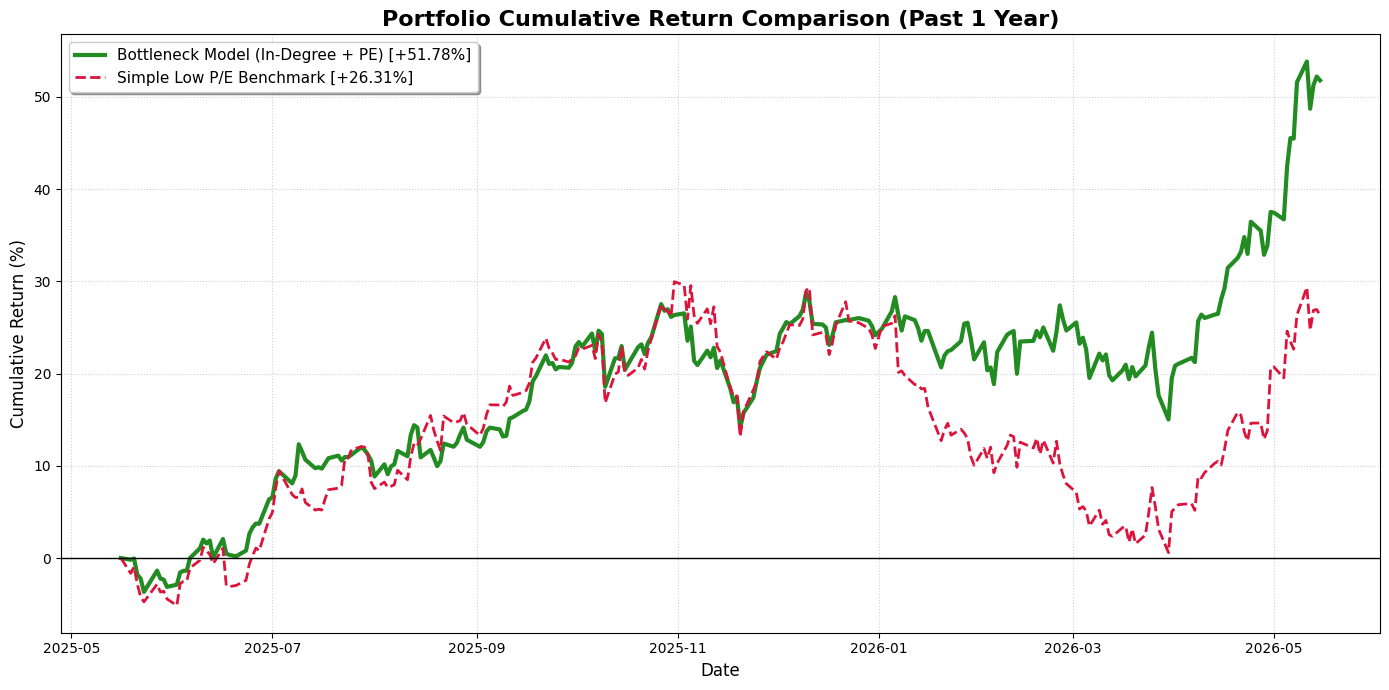

In [17]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 2025년 5월 당시 결과 기반 포트폴리오 구성
bottleneck_portfolio = ['HPE', 'MSFT', 'PTC', 'AMAT', 'QCOM', 'AAPL']
low_pe_portfolio = ['HPE', 'TRMB', 'FSLR', 'TEL', 'QCOM', 'SWKS']

# 데이터 수집을 위해 모든 티커 병합 (중복 제거)
all_tickers = list(set(bottleneck_portfolio + low_pe_portfolio))

print("지난 1년간의 일별 주가 데이터를 가져와 백테스팅을 진행합니다...")

# 최근 1년 데이터 다운로드
raw_data = yf.download(all_tickers, period='1y')

# 주가 종가(Close) 데이터만 추출 및 결측치 정제
df_close = raw_data['Close'].dropna()

# 2. 포트폴리오 수익률 계산 (투자 시작일 기준 주가를 100으로 자산 정규화)
# 이는 시작 시점에 모든 종목을 동일한 금액(동일 비중)으로 매수했음을 의미합니다.
df_normalized = (df_close / df_close.iloc[0]) * 100

# 일별 포트폴리오 가치 계산 (각 종목 자산의 평균값)
bottleneck_trend = df_normalized[bottleneck_portfolio].mean(axis=1)
low_pe_trend = df_normalized[low_pe_portfolio].mean(axis=1)

# 3. 최종 누적 수익률(Total Return %) 계산
final_bottleneck_return = bottleneck_trend.iloc[-1] - 100
final_low_pe_return = low_pe_trend.iloc[-1] - 100

print("\n" + "="*50)
print(f"   [ 1년간의 포트폴리오 최종 성적표 ]")
print(f"   ▶ Bottleneck Model Portfolio : {final_bottleneck_return:+.2f}%")
print(f"   ▶ Simple Low P/E Portfolio   : {final_low_pe_return:+.2f}%")
print(f"   ▶ 초과수익률 (Alpha)         : {final_bottleneck_return - final_low_pe_return:+.2f}%p")
print("="*50)

# 4. 일별 누적 수익률 추이 시각화
plt.figure(figsize=(14, 7))

# 수익률 추이 그래프 Plot (시작점을 0%로 맞추기 위해 100을 차감)
plt.plot(bottleneck_trend.index, bottleneck_trend - 100, 
         label=f'Bottleneck Model (In-Degree + PE) [{final_bottleneck_return:+.2f}%]', 
         color='forestgreen', linewidth=3)

plt.plot(low_pe_trend.index, low_pe_trend - 100, 
         label=f'Simple Low P/E Benchmark [{final_low_pe_return:+.2f}%]', 
         color='crimson', linestyle='--', linewidth=2)

# 그래프 디테일 스타일링
plt.title("Portfolio Cumulative Return Comparison (Past 1 Year)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return (%)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='black', linewidth=1, linestyle='-') # 원점선

# 범례 및 레이아웃 정돈
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()

# 그래프 출력
plt.show()

--- 계산된 포트폴리오별 투자 비중 ---
[Bottleneck 비중]
  HPE: 26.77%
  MSFT: 24.53%
  PTC: 17.56%
  AMAT: 12.04%
  QCOM: 9.64%
  AAPL: 9.46%

[Simple Low P/E 비중]
  HPE: 25.34%
  TRMB: 19.26%
  FSLR: 15.30%
  TEL: 14.48%
  QCOM: 13.68%
  SWKS: 11.94%

지난 1년간의 주가 데이터를 가져오는 중...


[*********************100%***********************]  10 of 10 completed



   [ 차등 가중치 투자 포트폴리오 최종 성적표 ]
   ▶ Score-Weighted Bottleneck : +47.07%
   ▶ Value-Weighted Low P/E    : +31.68%
   ▶ 가중치 기반 초과수익률 (Alpha) : +15.39%p


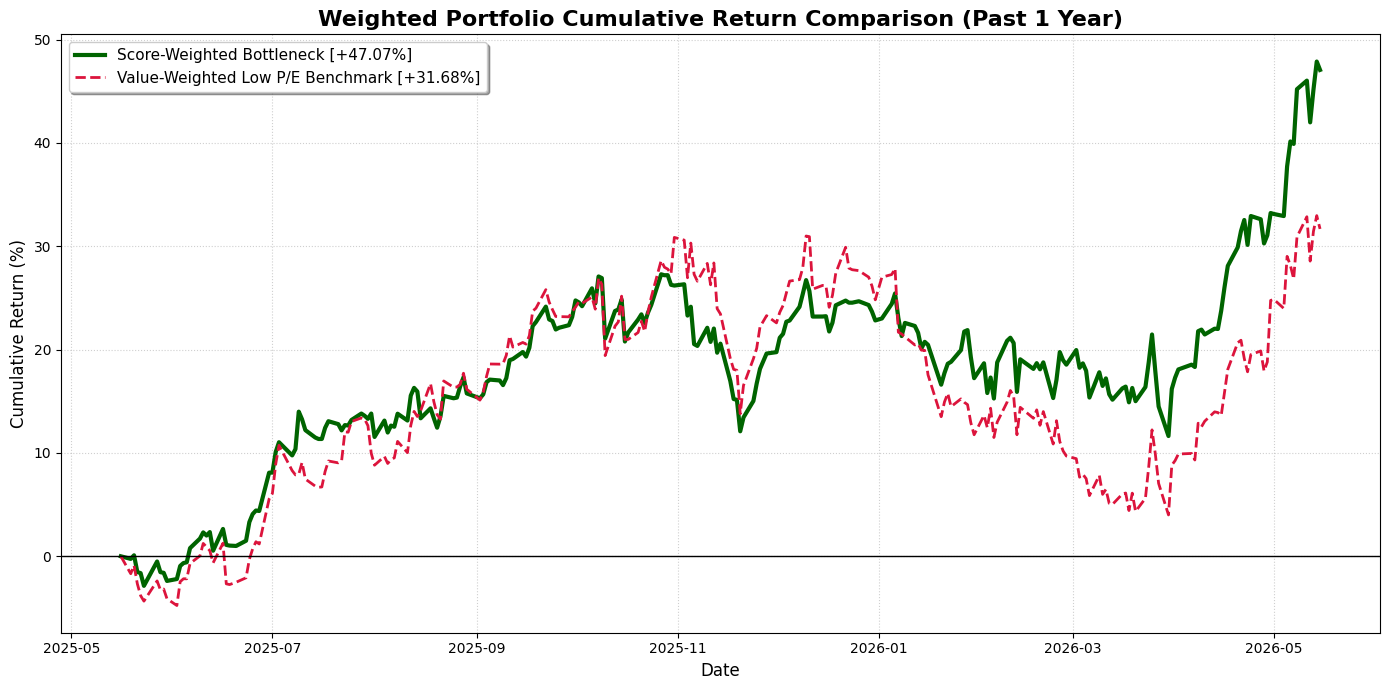

In [18]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 2025년 5월 당시 산출된 데이터 입력
bottleneck_scores = {
    'HPE': 0.5585, 'MSFT': 0.5118, 'PTC': 0.3664, 
    'AMAT': 0.2511, 'QCOM': 0.2012, 'AAPL': 0.1973
}

pe_ratios = {
    'HPE': 8.97, 'TRMB': 11.80, 'FSLR': 14.85, 
    'TEL': 15.70, 'QCOM': 16.61, 'SWKS': 19.04
}

# 2. 가중치(Weight) 계산 로직
# ① Bottleneck: 스코어 비율대로 가중치 부여 (점수가 높을수록 비중 Up)
b_sum = sum(bottleneck_scores.values())
b_weights = {ticker: score / b_sum for ticker, score in bottleneck_scores.items()}

# ② Low P/E: P/E의 역수(1/PE) 비율대로 가중치 부여 (P/E가 낮을수록 비중 Up)
inv_pe = {ticker: 1.0 / pe for ticker, pe in pe_ratios.items()}
pe_sum = sum(inv_pe.values())
pe_weights = {ticker: inv / pe_sum for ticker, inv in inv_pe.items()}

print("--- 계산된 포트폴리오별 투자 비중 ---")
print("[Bottleneck 비중]")
for k, v in b_weights.items(): print(f"  {k}: {v*100:.2f}%")
print("\n[Simple Low P/E 비중]")
for k, v in pe_weights.items(): print(f"  {k}: {v*100:.2f}%")

# 3. 데이터 수集
all_tickers = list(set(list(b_weights.keys()) + list(pe_weights.keys())))
print("\n지난 1년간의 주가 데이터를 가져오는 중...")
raw_data = yf.download(all_tickers, period='1y')
df_close = raw_data['Close'].dropna()

# 시작일 기준 주가 100으로 정규화
df_normalized = (df_close / df_close.iloc[0]) * 100

# 4. 가중치를 반영한 포트폴리오 일별 가치 계산
# 각 주가의 흐름에 계산된 고유 가중치(Series)를 곱한 후 합산
b_series = pd.Series(b_weights)
pe_series = pd.Series(pe_weights)

bottleneck_weighted_trend = (df_normalized[b_series.index] * b_series).sum(axis=1)
low_pe_weighted_trend = (df_normalized[pe_series.index] * pe_series).sum(axis=1)

# 최종 누적 수익률 계산
final_b_return = bottleneck_weighted_trend.iloc[-1] - 100
final_pe_return = low_pe_weighted_trend.iloc[-1] - 100

print("\n" + "="*50)
print(f"   [ 차등 가중치 투자 포트폴리오 최종 성적표 ]")
print(f"   ▶ Score-Weighted Bottleneck : {final_b_return:+.2f}%")
print(f"   ▶ Value-Weighted Low P/E    : {final_pe_return:+.2f}%")
print(f"   ▶ 가중치 기반 초과수익률 (Alpha) : {final_b_return - final_pe_return:+.2f}%p")
print("="*50)

# 5. 일별 누적 수익률 시각화
plt.figure(figsize=(14, 7))

plt.plot(bottleneck_weighted_trend.index, bottleneck_weighted_trend - 100, 
         label=f'Score-Weighted Bottleneck [{final_b_return:+.2f}%]', 
         color='darkgreen', linewidth=3)

plt.plot(low_pe_weighted_trend.index, low_pe_weighted_trend - 100, 
         label=f'Value-Weighted Low P/E Benchmark [{final_pe_return:+.2f}%]', 
         color='crimson', linestyle='--', linewidth=2)

plt.title("Weighted Portfolio Cumulative Return Comparison (Past 1 Year)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return (%)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='black', linewidth=1)

plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

1. 빅테크 CAPEX 데이터 수집 중...
2. 실시간 기업 프로필 및 P/E 비율 수집 중...
3. SEC EDGAR 최신 10-K 기반 관계 추출 시작 (대상: 48개 기업)...
추출된 실전 10-K 관계 수: 86


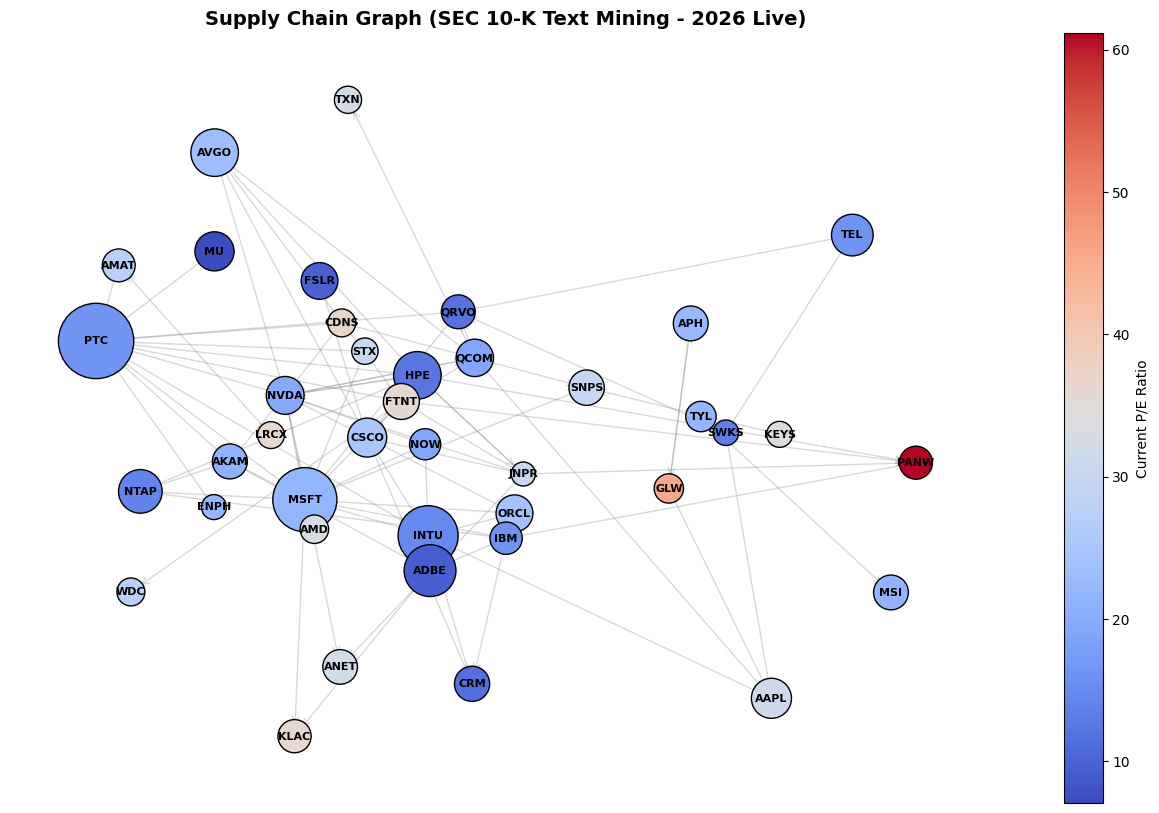

        In_Degree  Correlation         PE  Bottleneck_Score
Ticker                                                     
PTC            12        0.973  16.424313            1.3213
MSFT           11        0.965  21.799538            0.9162
INTU            6        0.940  14.839367            0.7846
ADBE            2        0.923   9.383757            0.5465
AVGO            5        0.962  23.247448            0.4361
HPE             2        0.986  12.145540            0.4360
NTAP            2        0.812  14.060415            0.3436
TEL             2        0.829  16.249052            0.3002
AAPL            4        0.925  31.319310            0.2663
MU              0        0.747   7.064195            0.2473
CSCO            4        0.407  24.934664            0.2444
NVDA            7       -0.362  19.714830            0.2212
QCOM            2        0.511  18.943850            0.2126
ORCL            2        0.823  24.021133            0.2024
FSLR            0        0.935   9.70891

In [ ]:
import yfinance as yf
import requests
import json
import time
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import re
from bs4 import BeautifulSoup

# 분석 대상 리스트
it_50_tickers = [
    'MSFT', 'AAPL', 'NVDA', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'CSCO', 'AMD', 'QCOM',
    'TXN', 'INTU', 'IBM', 'AMAT', 'MU', 'NOW', 'LRCX', 'ADI', 'PANW', 'KLAC',
    'SNPS', 'CDNS', 'MSI', 'APH', 'CDW', 'TEL', 'FTNT', 'ANET', 'KEYS', 'GLW', 
    'TER', 'STX', 'NTAP', 'FSLR', 'TYL', 'AKAM', 'GEN', 'JNPR', 'QRVO', 'SWKS', 
    'WDC', 'ENPH', 'TRMB', 'ZBRA', 'PTC', 'VRT', 'ETN', 'HPE'
]
big_tech = ['MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA']

# SEC 방화벽 통과를 위한 필수 헤더 설정
HEADERS = {
    'User-Agent': 'Academic ResearchProject YourEmail@domain.com',  # ⚠️ SEC EDGAR 규정상 본인의 실제 이메일로 변경해야 작동합니다.
    'Accept-Encoding': 'gzip, deflate'
}

def get_ticker_to_cik():
    """IT 48개 기업 전체의 CIK 및 공식 사명 매핑 딕셔너리"""
    local_ticker_to_cik = {
        'MSFT': '0000789019', 'AAPL': '0000320193', 'NVDA': '0001045810', 'AVGO': '0001730168', 
        'ORCL': '0001341439', 'CRM': '0001108524', 'ADBE': '0000796343', 'CSCO': '0000858877', 
        'AMD': '0000002488', 'QCOM': '0000804328', 'TXN': '0000097476', 'INTU': '0000896878', 
        'IBM': '0000051143', 'AMAT': '0000006951', 'MU': '0000723125', 'NOW': '0001373715', 
        'LRCX': '0000707549', 'ADI': '0000006281', 'PANW': '0001327568', 'KLAC': '0000319201', 
        'SNPS': '0000883241', 'CDNS': '0000813672', 'MSI': '0000068505', 'APH': '0000820313', 
        'CDW': '0001402064', 'TEL': '0001385157', 'FTNT': '0001262039', 'ANET': '0001591862', 
        'KEYS': '0001601046', 'GLW': '0000024741', 'TER': '0000097210', 'STX': '0001137789', 
        'NTAP': '0001002047', 'FSLR': '0001274494', 'TYL': '0000860731', 'AKAM': '0001086222', 
        'GEN': '0000849318', 'JNPR': '0001043604', 'QRVO': '0001602658', 'SWKS': '0000004127', 
        'WDC': '0001060394', 'ENPH': '0001463101', 'TRMB': '0000864749', 'ZBRA': '0000877212', 
        'PTC': '0000857002', 'VRT': '0001774759', 'ETN': '0001551182', 'HPE': '0001645590'
    }
    local_cik_to_name = {
        'MSFT': 'Microsoft', 'AAPL': 'Apple', 'NVDA': 'NVIDIA', 'AVGO': 'Broadcom', 
        'ORCL': 'Oracle', 'CRM': 'Salesforce', 'ADBE': 'Adobe', 'CSCO': 'Cisco Systems', 
        'AMD': 'Advanced Micro Devices', 'QCOM': 'QUALCOMM', 'TXN': 'Texas Instruments', 'INTU': 'Intuit', 
        'IBM': 'International Business Machines', 'AMAT': 'Applied Materials', 'MU': 'Micron Technology', 'NOW': 'ServiceNow', 
        'LRCX': 'Lam Research', 'ADI': 'Analog Devices', 'PANW': 'Palo Alto Networks', 'KLAC': 'KLA', 
        'SNPS': 'Synopsys', 'CDNS': 'Cadence Design Systems', 'MSI': 'Motorola Solutions', 'APH': 'Amphenol', 
        'CDW': 'CDW', 'TEL': 'TE Connectivity', 'FTNT': 'Fortinet', 'ANET': 'Arista Networks', 
        'KEYS': 'Keysight Technologies', 'GLW': 'Corning', 'TER': 'Teradyne', 'STX': 'Seagate Technology', 
        'NTAP': 'NetApp', 'FSLR': 'First Solar', 'TYL': 'Tyler Technologies', 'AKAM': 'Akamai Technologies', 
        'GEN': 'Gen Digital', 'JNPR': 'Juniper Networks', 'QRVO': 'Qorvo', 'SWKS': 'Skyworks Solutions', 
        'WDC': 'Western Digital', 'ENPH': 'Enphase Energy', 'TRMB': 'Trimble', 'ZBRA': 'Zebra Technologies', 
        'PTC': 'PTC', 'VRT': 'Vertiv Holdings', 'ETN': 'Eaton', 'HPE': 'Hewlett Packard Enterprise'
    }
    return local_ticker_to_cik, local_cik_to_name

def get_latest_10k_url(ticker, cik):
    """현재(2026년 5월) 시점에서 공시되어 있는 각 기업의 가장 최신 10-K 보고서 URL을 가져옵니다."""
    url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    try:
        res = requests.get(url, headers=HEADERS)
        if res.status_code != 200: return None
        submissions = res.json()['filings']['recent']
        for i in range(len(submissions['form'])):
            form_type = submissions['form'][i]
            filing_date = submissions['filingDate'][i]
            # 2026년 5월 현재 기준 가장 최신 10-K 타겟팅
            if form_type == '10-K' and filing_date <= "2026-05-16":
                acc_num = submissions['accessionNumber'][i].replace('-', '')
                doc_name = submissions['primaryDocument'][i]
                return f"https://www.sec.gov/Archives/edgar/data/{cik}/{acc_num}/{doc_name}"
    except: pass
    return None

def final_evolution_analysis_sec_version(tickers, customers):
    profiles = {}
    edges = []
    ticker_to_cik, ticker_to_name = get_ticker_to_cik()
    
    # 48개 완전체 노드로 필터링
    valid_tickers = [t for t in tickers if t in ticker_to_cik]
    
    # 1. 빅테크 데이터 수집 (수치금융은 yfinance 유지)
    print("1. 빅테크 CAPEX 데이터 수집 중...")
    cust_capex_list = []
    for t in customers:
        try:
            c = yf.Ticker(t)
            cf = c.cashflow.T
            if 'Capital Expenditure' in cf.columns:
                capex = cf['Capital Expenditure'].abs()
                capex.index = pd.to_datetime(capex.index).year
                cust_capex_list.append(capex.groupby(capex.index).last())
        except: continue
    
    if not cust_capex_list:
        print("고객사 CAPEX 데이터를 가져올 수 없습니다.")
        return pd.DataFrame()
        
    total_capex = pd.concat(cust_capex_list, axis=1).sum(axis=1)

    # 2. 기업 프로필 구축 (현재 실시간 P/E 데이터 확보)
    print("2. 실시간 기업 프로필 및 P/E 비율 수집 중...")
    for t in valid_tickers:
        try:
            stock = yf.Ticker(t)
            info = stock.info
            
            profiles[t] = {
                'name': ticker_to_name[t],
                'pe': info.get('forwardPE', info.get('trailingPE', 30)),
                'stock_obj': stock
            }
        except: continue

    # 3. SEC EDGAR 10-K 원문 기반 관계 추출 (Proximity 문맥 탐색으로 환각 치료)
    print(f"3. SEC EDGAR 최신 10-K 기반 관계 추출 시작 (대상: {len(profiles)}개 기업)...")
    rel_keywords = ['partner', 'supply', 'provide', 'infrastructure', 'platform', 'customer', 'use', 'build', 'work']

    for t in profiles.keys():
        cik = ticker_to_cik[t]
        url = get_latest_10k_url(t, cik)
        if not url: continue
        
        try:
            # SEC DDOS 초당 요청 제한 준수를 위한 안전 지연
            time.sleep(0.2) 
            res = requests.get(url, headers=HEADERS)
            if res.status_code != 200: continue
            
            soup = BeautifulSoup(res.text, 'html.parser')
            text = soup.get_text(separator=' ').lower()
            text = re.sub(r'\s+', ' ', text)
            
            for target_t in profiles.keys():
                if t == target_t: continue
                target_name = profiles[target_t]['name'].lower()
                
                # 문서 내 타겟 사명이나 티커 언급 확인
                if target_name in text or target_t.lower() in text:
                    for kw in rel_keywords:
                        # 키워드 등장 후 150자 이내에 타겟 기업 풀네임 등장 여부 검증
                        pattern = rf"{kw}.{{0,150}}{re.escape(target_name)}"
                        if re.search(pattern, text):
                            edges.append((t, target_t))
                            break
        except: continue

    print(f"추출된 실전 10-K 관계 수: {len(edges)}")

    if not edges:
        print("추출된 관계가 없습니다. 데이터 환경을 확인하세요.")
        return pd.DataFrame()

    # 4. 그래프 및 수치 분석
    G = nx.DiGraph()
    G.add_edges_from(edges)
    
    in_degrees = dict(G.in_degree())
    max_in = max(in_degrees.values()) if in_degrees else 1
    
    analysis_results = []
    for t in G.nodes():
        if t in profiles:
            try:
                rev_df = profiles[t]['stock_obj'].financials.T
                if 'Total Revenue' in rev_df.columns:
                    rev = rev_df['Total Revenue']
                    rev.index = pd.to_datetime(rev.index).year
                    rev = rev.groupby(rev.index).last()
                    
                    combined = pd.DataFrame({'Capex': total_capex, 'Rev': rev}).dropna()
                    corr = combined.corr().iloc[0, 1] if len(combined) >= 2 else 0
                    
                    norm_in = in_degrees.get(t, 0) / max_in
                    score = ((norm_in + 0.1) * (corr + 1)) / (max(profiles[t]['pe'], 5) / 10)
                    
                    analysis_results.append({
                        'Ticker': t,
                        'In_Degree': in_degrees.get(t, 0),
                        'Correlation': round(corr, 3),
                        'PE': profiles[t]['pe'],
                        'Bottleneck_Score': round(score, 4)
                    })
            except: continue

    # 5. 데이터프레임 생성 및 인덱스 설정
    if not analysis_results:
        print("분석 결과 데이터가 생성되지 않았습니다.")
        return pd.DataFrame()

    res_df = pd.DataFrame(analysis_results)
    if 'Ticker' in res_df.columns:
        res_df = res_df.set_index('Ticker')
    
    # 6. 시각화
    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(G, k=0.5, seed=42)
    node_sizes = [res_df.loc[n, 'Bottleneck_Score'] * 2000 + 300 if n in res_df.index else 300 for n in G.nodes()]
    node_colors = [profiles[n]['pe'] if n in profiles else 30 for n in G.nodes()]

    nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.coolwarm, edgecolors='black')
    nx.draw_networkx_edges(G, pos, alpha=0.3, arrowstyle='->', arrowsize=12, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    plt.title("Supply Chain Graph (SEC 10-K Text Mining - 2026 Live)", fontsize=14, fontweight='bold')
    plt.colorbar(nodes, label="Current P/E Ratio")
    plt.axis('off')
    plt.show()

    return res_df.sort_values(by='Bottleneck_Score', ascending=False)

# 실행 및 결과 도출
final_report = final_evolution_analysis_sec_version(it_50_tickers, big_tech)
if not final_report.empty:
    print(final_report.head(20))